# Evaluation: Basic RAG vs advanced agentic RAG (OpenAI)

- **Questions:** first 20 bullet items in `test_questions.md` (lines starting with `*`).
- **Basic RAG:** `RagRetriever` + `answer_with_rag` (`src.rag`), generator `gpt-4o-mini`.
- **Advanced RAG:** `AdvancedRegulationAssistant` with OpenAI synthesizer (`src.advanced_rag`), see the diagram below for the system design. 
- **Judge:** `gpt-4o-mini` compares the two answers per question (JSON: preference, scores, rationale).

Requires `.env` with `OPENAI_API_KEY`, Pinecone settings, and ingested `chunks/` for retrieval.



### Advanced Rag diagram

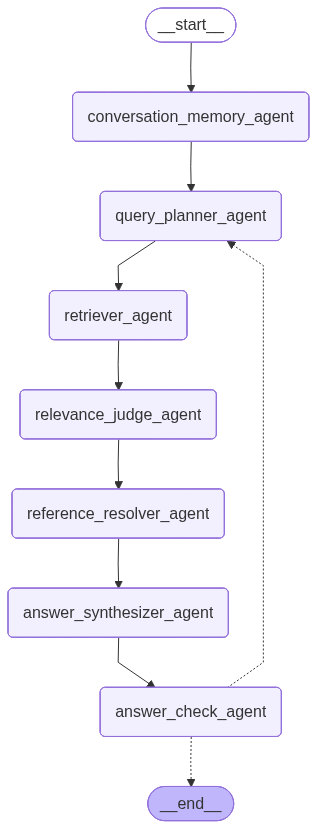

[ok] wrote advanced_rag_actual_langgraph.png


In [2]:
# LangGraph visualization: advanced_rag graph (PNG)
# This version plots the *intended retry* logic:
# - If answer check fails on first pass, retry goes back through the Query Planner.
# - On that retry, retrieval uses a larger k (state bumps top_k from 8 -> 12).

from IPython.display import Image, display
from langgraph.graph import END, START, StateGraph

from src.advanced_rag.nodes import (
    answer_check_node,
    answer_synthesizer_node,
    conversation_memory_node,
    query_planner_node,
    reference_resolver_node,
    relevance_judge_node,
    retriever_node,
)
from src.advanced_rag.state import AdvancedRagState

try:
    from langchain_core.runnables.graph import MermaidDrawMethod
except Exception:  # pragma: no cover
    MermaidDrawMethod = None  # type: ignore


# NOTE: These are placeholders so we can *draw* the graph without running it.
# The lambdas capture them but nothing is executed during rendering.
client = object()
retriever = object()
model = "gpt-4o-mini"
TOP_K = 8
RETRY_TOP_K = 12


graph = StateGraph(AdvancedRagState)

graph.add_node(
    "conversation_memory_agent",
    lambda s: conversation_memory_node(s, client=client, model=model),
)

graph.add_node(
    "query_planner_agent",
    lambda s: query_planner_node(s, client=client, model=model),
)

graph.add_node(
    "retriever_agent",
    # `retriever_node` will actually use `state["top_k"]` if present; otherwise it falls back to TOP_K.
    lambda s: retriever_node(s, retriever=retriever, top_k=TOP_K),
)

graph.add_node(
    "relevance_judge_agent",
    lambda s: relevance_judge_node(s, client=client, model=model),
)

graph.add_node(
    "reference_resolver_agent",
    lambda s: reference_resolver_node(s, client=client, model=model, retriever=retriever),
)

synth_model = model

graph.add_node(
    "answer_synthesizer_agent",
    lambda s: answer_synthesizer_node(
        s,
        client=client,
        openai_model=synth_model,
    ),
)

graph.add_node(
    "answer_check_agent",
    # `answer_check_node` will (on first failure) increment retry_count,
    # append an additional_query_hint to the rewritten query, and bump state["top_k"] to >= RETRY_TOP_K.
    lambda s: answer_check_node(s, client=client, model=model),
)

# Edges

graph.add_edge(START, "conversation_memory_agent")

graph.add_edge("conversation_memory_agent", "query_planner_agent")

graph.add_edge("query_planner_agent", "retriever_agent")

graph.add_edge("retriever_agent", "relevance_judge_agent")

graph.add_edge("relevance_judge_agent", "reference_resolver_agent")

graph.add_edge("reference_resolver_agent", "answer_synthesizer_agent")

graph.add_edge("answer_synthesizer_agent", "answer_check_agent")


def _route_after_check(state: AdvancedRagState) -> str:
    if state.get("answer_supported", False):
        return END
    if state.get("retry_count", 0) >= 1:
        return END
    return "query_planner_agent"


graph.add_conditional_edges(
    "answer_check_agent",
    _route_after_check,
    {
        END: END,
        "query_planner_agent": "query_planner_agent",
    },
)

app = graph.compile()

# Render PNG in notebook (and save to disk)
kwargs = {}
if MermaidDrawMethod is not None:
    kwargs["draw_method"] = MermaidDrawMethod.API

png_bytes = app.get_graph().draw_mermaid_png(**kwargs)

out_path = "advanced_rag_actual_langgraph.png"
with open(out_path, "wb") as f:
    f.write(png_bytes)

display(Image(png_bytes))
print(f"[ok] wrote {out_path}")


In [1]:
from __future__ import annotations

import json
import os
import re
from pathlib import Path

from dotenv import load_dotenv
from openai import OpenAI

from src.advanced_rag import AdvancedRegulationAssistant
from src.rag.answer import answer_with_rag, build_context
from src.rag.retriever import RagRetriever

load_dotenv()

REPO = Path.cwd()
TEST_QUESTIONS_PATH = REPO / "test_questions.md"
N_QUESTIONS = 20
TOP_K = 8
GEN_MODEL = "gpt-4o-mini"
JUDGE_MODEL = "gpt-4o-mini"
MAX_CONTEXT_CHARS = 20000


def load_bullet_questions(md_path: Path, limit: int) -> list[str]:
    """First `limit` lines that look like markdown bullets: '* ...'"""
    text = md_path.read_text(encoding="utf-8")
    out: list[str] = []
    for line in text.splitlines():
        m = re.match(r"^\*\s+(.+?)\s*$", line.strip())
        if m:
            out.append(m.group(1).strip())
            if len(out) >= limit:
                break
    return out


EVAL_QUESTIONS = load_bullet_questions(TEST_QUESTIONS_PATH, N_QUESTIONS)
assert len(EVAL_QUESTIONS) == N_QUESTIONS, (
    f"Expected {N_QUESTIONS} bullet questions in {TEST_QUESTIONS_PATH}, got {len(EVAL_QUESTIONS)}"
)
for i, q in enumerate(EVAL_QUESTIONS, start=1):
    print(f"{i:2}. {q}")

/Users/yihaochen/Desktop/MLDS GenAI/multi_agent_rags_f1_regulations/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 1. What is the scope of the Power Unit Financial Regulations?
 2. What are the objectives of the Power Unit Financial Regulations?
 3. Who interprets and applies these regulations?
 4. When do these regulations come into force?
 5. What must a Power Unit Manufacturer do to demonstrate compliance with the Power Unit Cost Cap?
 6. What is the Power Unit Cost Cap for the N-3, N-2, and N-1 reporting periods?
 7. What is the Power Unit Cost Cap in a manufacturer’s inaugural season?
 8. What is a Reporting Group?
 9. What happens if a manufacturer has incurred less than 95% of Power Unit Activity costs itself?
10. What costs are excluded under Article E3?
11. Are marketing activities included in Relevant Costs?
12. Are finance costs excluded from Relevant Costs?
13. Are corporate income taxes excluded?
14. Are employee bonus costs fully excluded, or is there a cap?
15. Are health and safety costs excluded?
16. Are transportation costs excluded?
17. Are maternity and paternity leave costs ex

In [2]:
if not os.environ.get("OPENAI_API_KEY"):
    raise RuntimeError("Set OPENAI_API_KEY (e.g. in .env)")

# Ensure the embedding model matches your Pinecone index dimension.
# `regs-2026-bgebased` typically corresponds to BGE-base (768-dim).
os.environ["EMBEDDING_MODEL"] = os.getenv("EMBEDDING_MODEL", "BAAI/bge-base-en")

INDEX_NAME = os.getenv("PINECONE_INDEX_NAME", "regs-2026-bgebased")
NAMESPACE = os.getenv("PINECONE_NAMESPACE", "regulations-2026")
PINECONE_HOST = os.getenv("PINECONE_HOST")

client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

retriever = RagRetriever(
    model_name=os.environ["EMBEDDING_MODEL"],
    index_name=INDEX_NAME,
    host=PINECONE_HOST,
    namespace=NAMESPACE,
    chunks_root="chunks",
)

assistant = AdvancedRegulationAssistant(
    llm_model=GEN_MODEL,
    answer_synthesizer_openai_model=GEN_MODEL,
    top_k=TOP_K,
    chunks_root="chunks",
    index_name=INDEX_NAME,
    host=PINECONE_HOST,
    namespace=NAMESPACE,
)

print(f"index={INDEX_NAME} namespace={NAMESPACE} gen={GEN_MODEL} judge={JUDGE_MODEL} embed={os.environ['EMBEDDING_MODEL']}")

index=regs-2026-bgebased namespace=regulations-2026 gen=gpt-4o-mini judge=gpt-4o-mini embed=BAAI/bge-base-en


In [3]:
from typing import Any, Iterable


def _chunk_label(metadata: dict[str, Any]) -> str:
    """Short human label to help the LLM judge relevance."""
    keys = [
        "article_id",
        "appendix_id",
        "parent_clause_id",
        "clause_id",
        "clause_ids",
        "section",
        "document_title",
        "source_pdf",
        "page",
    ]
    parts: list[str] = []
    for k in keys:
        v = metadata.get(k)
        if v is None or v == "":
            continue
        if isinstance(v, list):
            v = ",".join(str(x) for x in v[:5])
        parts.append(f"{k}={v}")
    return " | ".join(parts)[:180]


def _as_eval_chunk(x: Any) -> dict:
    """Normalize both basic and advanced chunks into a single dict schema."""
    # Basic RAG: src.rag.retriever.RetrievalResult
    if hasattr(x, "id") and hasattr(x, "metadata"):
        return {
            "id": str(getattr(x, "id")),
            "score": float(getattr(x, "score", 0.0) or 0.0),
            "text": (getattr(x, "text", None) or ""),
            "metadata": dict(getattr(x, "metadata", {}) or {}),
            "source": "basic",
        }

    # Advanced RAG: src.advanced_rag.state.ChunkDoc (TypedDict)
    if isinstance(x, dict) and "id" in x and "text" in x:
        return {
            "id": str(x.get("id", "")),
            "score": float(x.get("score", 0.0) or 0.0),
            "text": str(x.get("text", "") or ""),
            "metadata": dict(x.get("metadata", {}) or {}),
            "source": str(x.get("source", "advanced")),
        }

    raise TypeError(f"Unsupported chunk type: {type(x)}")


def run_basic_rag(question: str) -> dict:
    hits = retriever.retrieve(question, top_k=TOP_K)
    ctx = build_context(hits, max_context_chars=MAX_CONTEXT_CHARS)
    if not ctx.strip():
        ans = "(no retrieval context)"
    else:
        ans = answer_with_rag(
            query=question,
            context=ctx,
            model=GEN_MODEL,
            client=client,
        )
    return {
        "answer": (ans or "").strip(),
        "chunks": [_as_eval_chunk(h) for h in hits],
    }


def run_advanced_rag(question: str, idx: int) -> dict:
    # Fresh session per question so memory does not carry across the eval set
    r = assistant.ask(question, session_id=f"eval-advanced-{idx}")
    # `r.citations` are the advanced RAG's final selected context chunks
    return {
        "answer": (r.answer or "").strip(),
        "chunks": [_as_eval_chunk(c) for c in (r.citations or [])],
    }


JUDGE_SYSTEM = """You are an expert evaluator for F1 Power Unit Financial Regulations Q&A.
You compare two answers to the same user question.
- Answer A was produced by **basic RAG**: retrieve chunks, then one LLM call over that context.
- Answer B was produced by **advanced agentic RAG**: multi-agent pipeline (planning, retrieval, judging, synthesis) with OpenAI.

Evaluate grounding (use of regulation concepts, avoiding obvious hallucination), correctness, and whether the answer addresses what was asked.
Return **only** a JSON object with exactly these keys:
- "preferred": one of "A", "B", "tie" (which answer is better overall; "tie" if similar quality)
- "base_rag_score": integer 1-5 (quality of Answer A)
- "advanced_rag_score": integer 1-5 (quality of Answer B)
- "rationale": string, at most 4 short sentences explaining the comparison"""


def judge_pair(question: str, answer_a: str, answer_b: str) -> dict:
    payload = (
        f"Question:\n{question}\n\n"
        f"Answer A (basic RAG):\n{answer_a}\n\n"
        f"Answer B (advanced agentic RAG):\n{answer_b}"
    )
    resp = client.chat.completions.create(
        model=JUDGE_MODEL,
        temperature=0,
        response_format={"type": "json_object"},
        messages=[
            {"role": "system", "content": JUDGE_SYSTEM},
            {"role": "user", "content": payload},
        ],
    )
    raw = (resp.choices[0].message.content or "").strip()
    return json.loads(raw)


RETRIEVAL_JUDGE_MODEL = "gpt-4o-mini"

RETRIEVAL_JUDGE_SYSTEM = """You judge retrieval quality for a RAG system.
Given a question and a set of candidate chunks, mark which chunks are relevant for answering the question.
A chunk is relevant if it contains definitions, rules, thresholds, scope, responsibilities, dates, or procedures that directly help answer the question.

Return ONLY a JSON object with keys:
- "relevant_chunk_ids": array of chunk ids judged relevant
- "notes": short string (<=2 sentences)"""


def judge_relevant_chunk_ids(question: str, chunks: list[dict], *, max_chars_per_chunk: int = 900) -> set[str]:
    items = []
    for c in chunks:
        text = (c.get("text") or "").strip().replace("\u0000", "")
        if len(text) > max_chars_per_chunk:
            text = text[:max_chars_per_chunk] + "…"
        items.append(
            {
                "id": c.get("id"),
                "label": _chunk_label(c.get("metadata", {}) or {}),
                "text": text,
            }
        )

    payload = json.dumps({"question": question, "chunks": items}, ensure_ascii=False)
    resp = client.chat.completions.create(
        model=RETRIEVAL_JUDGE_MODEL,
        temperature=0,
        response_format={"type": "json_object"},
        messages=[
            {"role": "system", "content": RETRIEVAL_JUDGE_SYSTEM},
            {"role": "user", "content": payload},
        ],
    )
    raw = (resp.choices[0].message.content or "").strip()
    obj = json.loads(raw)
    ids = obj.get("relevant_chunk_ids", [])
    if not isinstance(ids, list):
        return set()
    return {str(x) for x in ids if str(x).strip()}


def _unique_by_id(chunks: Iterable[dict]) -> list[dict]:
    out: list[dict] = []
    seen: set[str] = set()
    for c in chunks:
        cid = str(c.get("id", "")).strip()
        if not cid or cid in seen:
            continue
        seen.add(cid)
        out.append(c)
    return out


def ir_metrics_at_k(retrieved_ids: list[str], relevant_ids: set[str], *, k: int) -> dict:
    ids = [x for x in retrieved_ids if x]
    top = ids[:k]
    rel_ranks = [i for i, cid in enumerate(top, start=1) if cid in relevant_ids]

    precision = (len(rel_ranks) / k) if k > 0 else 0.0
    recall = (len(rel_ranks) / len(relevant_ids)) if relevant_ids else None
    mrr = (1.0 / rel_ranks[0]) if rel_ranks else 0.0

    return {
        f"precision@{k}": precision,
        f"recall@{k}": recall,
        "mrr": mrr,
        "relevant_found": len(rel_ranks),
        "relevant_total": len(relevant_ids),
    }


In [4]:
rows: list[dict] = []

k = TOP_K

for i, q in enumerate(EVAL_QUESTIONS, start=1):
    print(f"\n--- Q{i}/{len(EVAL_QUESTIONS)} ---")
    print(q[:100] + ("…" if len(q) > 100 else ""))

    base = run_basic_rag(q)
    adv = run_advanced_rag(q, i)

    verdict = judge_pair(q, base.get("answer", ""), adv.get("answer", ""))

    base_chunks = list(base.get("chunks") or [])
    adv_chunks = list(adv.get("chunks") or [])

    # Pool both systems' chunks, judge relevance once, then score each system vs the same relevance set.
    pool = _unique_by_id([*base_chunks, *adv_chunks])
    relevant_ids = judge_relevant_chunk_ids(q, pool)

    base_ids = [str(c.get("id", "")) for c in base_chunks]
    adv_ids = [str(c.get("id", "")) for c in adv_chunks]

    base_m = ir_metrics_at_k(base_ids, relevant_ids, k=k)
    adv_m = ir_metrics_at_k(adv_ids, relevant_ids, k=k)

    rows.append(
        {
            "i": i,
            "question": q,
            "basic_rag_answer": base.get("answer", ""),
            "advanced_rag_answer": adv.get("answer", ""),
            "judge_preferred": verdict.get("preferred"),
            "judge_base_score": verdict.get("base_rag_score"),
            "judge_advanced_score": verdict.get("advanced_rag_score"),
            "judge_rationale": verdict.get("rationale"),
            # Retrieval quality (LLM-judged relevance + IR metrics)
            f"basic_precision@{k}": base_m.get(f"precision@{k}"),
            f"basic_recall@{k}": base_m.get(f"recall@{k}"),
            "basic_mrr": base_m.get("mrr"),
            f"advanced_precision@{k}": adv_m.get(f"precision@{k}"),
            f"advanced_recall@{k}": adv_m.get(f"recall@{k}"),
            "advanced_mrr": adv_m.get("mrr"),
            "pool_relevant_total": base_m.get("relevant_total"),
            "basic_relevant_found": base_m.get("relevant_found"),
            "advanced_relevant_found": adv_m.get("relevant_found"),
        }
    )

    print(
        "preferred:",
        verdict.get("preferred"),
        "| scores A/B:",
        verdict.get("base_rag_score"),
        "/",
        verdict.get("advanced_rag_score"),
        f"| P@{k} basic/adv:",
        round(float(base_m.get(f"precision@{k}") or 0.0), 3),
        "/",
        round(float(adv_m.get(f"precision@{k}") or 0.0), 3),
        "| MRR basic/adv:",
        round(float(base_m.get("mrr") or 0.0), 3),
        "/",
        round(float(adv_m.get("mrr") or 0.0), 3),
    )

rows


--- Q1/20 ---
What is the scope of the Power Unit Financial Regulations?
preferred: B | scores A/B: 4 / 5 | P@8 basic/adv: 0.25 / 0.125 | MRR basic/adv: 0.167 / 1.0

--- Q2/20 ---
What are the objectives of the Power Unit Financial Regulations?
preferred: tie | scores A/B: 5 / 5 | P@8 basic/adv: 0.125 / 0.125 | MRR basic/adv: 0.143 / 1.0

--- Q3/20 ---
Who interprets and applies these regulations?
preferred: B | scores A/B: 4 / 5 | P@8 basic/adv: 0.0 / 0.375 | MRR basic/adv: 0.0 / 1.0

--- Q4/20 ---
When do these regulations come into force?
preferred: B | scores A/B: 4 / 5 | P@8 basic/adv: 0.25 / 0.375 | MRR basic/adv: 1.0 / 1.0

--- Q5/20 ---
What must a Power Unit Manufacturer do to demonstrate compliance with the Power Unit Cost Cap?
preferred: A | scores A/B: 5 / 3 | P@8 basic/adv: 0.375 / 0.375 | MRR basic/adv: 1.0 / 1.0

--- Q6/20 ---
What is the Power Unit Cost Cap for the N-3, N-2, and N-1 reporting periods?
preferred: A | scores A/B: 4 / 2 | P@8 basic/adv: 0.25 / 0.0 | MRR b

[{'i': 1,
  'question': 'What is the scope of the Power Unit Financial Regulations?',
  'basic_rag_answer': 'The scope of the Power Unit Financial Regulations includes the financial oversight and compliance requirements for Power Unit Manufacturers intending to homologate Power Units for Formula 1 teams starting from 2026. These regulations establish a Power Unit Cost Cap, reporting obligations, and the framework for regulatory functions of the Cost Cap Administration. They come into effect on January 1, 2026, for Reporting Periods commencing on or after that date, and apply to all Power Unit Manufacturers involved in the Championship from that time [Chunk 1, Chunk 8].',
  'advanced_rag_answer': 'The Power Unit Financial Regulations come into force on 1 January 2026 and apply to Reporting Periods commencing on or after that date. They are part of the terms for homologating Power Units for F1 Teams from 2026 onwards, binding Power Unit Manufacturers to comply from the start of their N-3

In [5]:
# Summary (run after the eval cell)
import csv
from collections import Counter
from statistics import mean

prefs = [str(r["judge_preferred"] or "").strip().upper() for r in rows]
print("Judge preferences (gpt-4o-mini):")
for k, v in sorted(Counter(prefs).items(), key=lambda kv: -kv[1]):
    print(f"  {k}: {v}")

def _num(x):
    try:
        return float(x)
    except (TypeError, ValueError):
        return None


def _mean(xs):
    xs = [x for x in xs if x is not None]
    return round(mean(xs), 3) if xs else None


# Answer quality
bs = [v for r in rows if (v := _num(r.get("judge_base_score"))) is not None]
ad = [v for r in rows if (v := _num(r.get("judge_advanced_score"))) is not None]
print()
_mb = _mean(bs)
_ma = _mean(ad)
print(f"Mean answer scores — basic RAG: {_mb if _mb is not None else 'n/a'} | advanced: {_ma if _ma is not None else 'n/a'}")


# Retrieval quality
if rows:
    p_key = next((k for k in rows[0].keys() if k.startswith("basic_precision@")), None)
    r_key = next((k for k in rows[0].keys() if k.startswith("basic_recall@")), None)
    if p_key:
        bp = _mean([_num(r.get(p_key)) for r in rows])
        ap = _mean([_num(r.get(p_key.replace("basic_", "advanced_"))) for r in rows])
        print(f"Mean retrieval {p_key} — basic: {bp if bp is not None else 'n/a'} | advanced: {ap if ap is not None else 'n/a'}")
    if r_key:
        br = _mean([_num(r.get(r_key)) for r in rows])
        ar = _mean([_num(r.get(r_key.replace("basic_", "advanced_"))) for r in rows])
        print(f"Mean retrieval {r_key} — basic: {br if br is not None else 'n/a'} | advanced: {ar if ar is not None else 'n/a'}")

bmrr = _mean([_num(r.get("basic_mrr")) for r in rows])
amrr = _mean([_num(r.get("advanced_mrr")) for r in rows])
print(f"Mean retrieval MRR — basic: {bmrr if bmrr is not None else 'n/a'} | advanced: {amrr if amrr is not None else 'n/a'}")


# Write CSV
out_csv = REPO / "eval_basic_vs_advanced_openai.csv"
fieldnames = list(rows[0].keys()) if rows else []
if fieldnames:
    with out_csv.open("w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=fieldnames, extrasaction="ignore")
        w.writeheader()
        w.writerows(rows)
    print(f"Wrote {out_csv}")


Judge preferences (gpt-4o-mini):
  B: 10
  A: 9
  TIE: 1

Mean answer scores — basic RAG: 3.85 | advanced: 3.7
Mean retrieval basic_precision@8 — basic: 0.194 | advanced: 0.125
Mean retrieval basic_recall@8 — basic: 0.875 | advanced: 0.525
Mean retrieval MRR — basic: 0.62 | advanced: 0.6
Wrote /Users/yihaochen/Desktop/MLDS GenAI/multi_agent_rags_f1_regulations/eval_basic_vs_advanced_openai.csv


In [ ]:
# see tok k results of what is a reporting group
# Show the top-k retrieval results of "What is a Reporting Group?" using the existing retriever/QA pipeline.
# This assumes you have a retriever or similar function available from earlier notebook cells, e.g. `retriever` or relevant RAG pipeline.

QUESTION = "What is a Reporting Group?"

# If you have a retriever object that exposes a .retrieve or .search or .__call__ method, adapt accordingly.
# Some common names might be: retriever, vectorstore, db, or pipeline.

# TOP_K can be changed to see more or fewer results
TOP_K = 5

try:
    # Try different names for your retriever/vectorstore object or pipeline as appropriate
    results = retriever.retrieve(QUESTION, top_k=TOP_K)
except Exception as e:
    # Try fallback to 'vectorstore' if retriever does not exist
    try:
        results = vectorstore.similarity_search(QUESTION, k=TOP_K)
    except Exception as e2:
        print("Unable to obtain retrieval results. Please check that your retriever/vectorstore pipeline is available.")
        results = []

if not results:
    print("No retrieval results found or retriever not defined.")
else:
    print(f"\nTop {TOP_K} chunks for: \"{QUESTION}\"")
    for i, chunk in enumerate(results):
        # Try the common fields for text chunk:
        chunk_text = chunk.get("text", "") if isinstance(chunk, dict) else str(chunk)
        print(f"\n--- Chunk #{i+1} ---")
        print(chunk_text[:1500])  # Print up to 1500 chars for readability
        # Optionally print metadata if available
        if isinstance(chunk, dict) and "metadata" in chunk:
            print("Metadata:", chunk["metadata"])


Top 5 chunks for: "What is a Reporting Group?"

--- Chunk #1 ---
RetrievalResult(id='ch_6cdff2d09ee9424c7540', score=0.643978119, metadata={'article_id': 'E5', 'chunk_scope': 'clause', 'clause_ids': ['E5.2', 'E5.2.1'], 'has_table': False, 'page_indices': ['18'], 'parent_clause_id': 'E5.2', 'scope': 'article', 'source_file': 'FIA 2026 F1 Regulations - Section E [Financial Regulations - Power Unit Manufacturers] - Iss 03 - 2025-12-10.pdf_by_PaddleOCR-VL_no_strike.chunks.jsonl', 'source_row': 12}, text='E5.2 Interim Reporting Documentation\n\nE5.2.1 By the Interim Reporting Deadline, a Power Unit Manufacturer must submit the following to the Cost Cap Administration (the " Interim Reporting Documentation "):\n\na. the Reporting Group Documentation;\n\nb. the Interim Financial Reporting Documentation; and\n\nc. the Declarations.')

--- Chunk #2 ---
RetrievalResult(id='ch_1b3e7e56e36eab0c43d0', score=0.641750336, metadata={'article_id': 'D4', 'chunk_scope': 'clause_with_table', 'clause_ids'